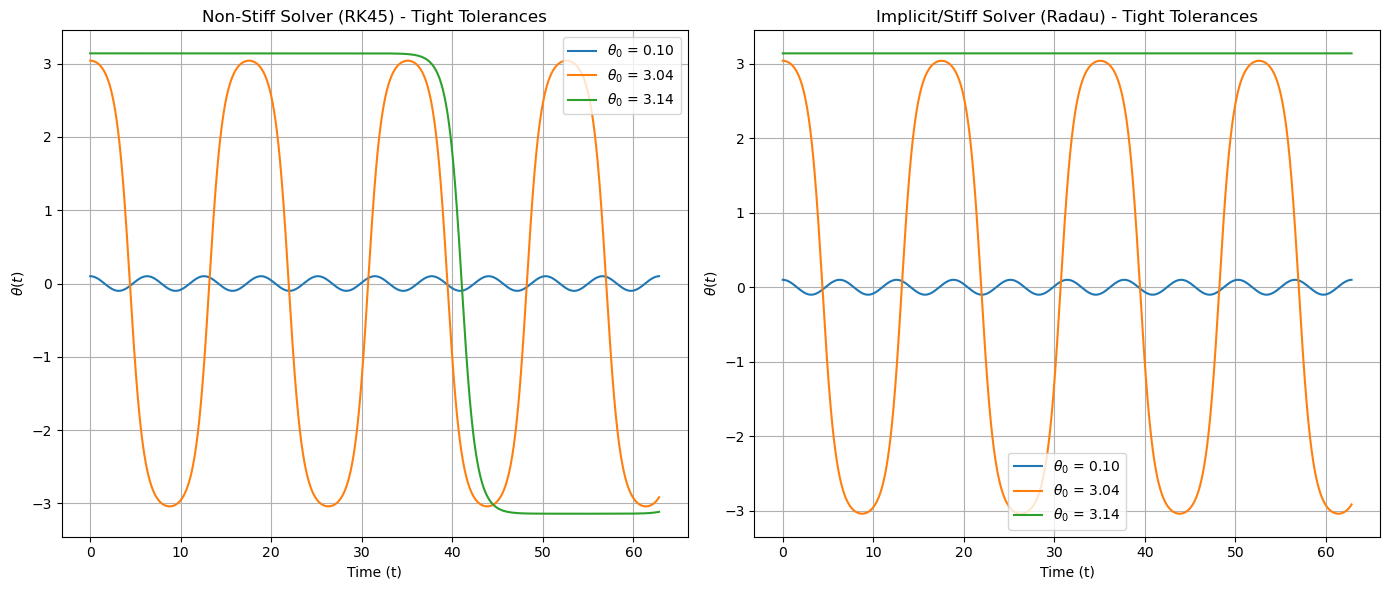

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the first-order ODE system for the pendulum
def pendulum_system(t, x):
    return [x[1], -np.sin(x[0])]

# Simulation parameters (as specified in the assignment: t in [0, 20*pi])
t_span = (0, 20 * np.pi)
t_eval = np.linspace(0, 20 * np.pi, 5000)
theta_0_list = [0.1, np.pi - 0.1, np.pi]

# Strict tolerances prevent the solvers from injecting artificial numerical noise 
# or taking overly aggressive step sizes.
RTOL = 1e-10
ATOL = 1e-13

plt.figure(figsize=(14, 6))

# 1. Non-stiff Solver (RK45)
plt.subplot(1, 2, 1)
for theta_0 in theta_0_list:
    sol = solve_ivp(pendulum_system, t_span, [theta_0, 0], method='RK45',
                     t_eval=t_eval, rtol=RTOL, atol=ATOL)
    plt.plot(sol.t, sol.y[0], label=f'$\\theta_0$ = {theta_0:.2f}')
plt.title('Non-Stiff Solver (RK45) - Tight Tolerances')
plt.xlabel('Time (t)')
plt.ylabel('$\\theta(t)$')
plt.grid(True)
plt.legend()

# 2. Stiff Solver (Radau)
plt.subplot(1, 2, 2)
for theta_0 in theta_0_list:
    sol = solve_ivp(pendulum_system, t_span, [theta_0, 0], method='Radau',
                     t_eval=t_eval, rtol=RTOL, atol=ATOL)
    plt.plot(sol.t, sol.y[0], label=f'$\\theta_0$ = {theta_0:.2f}')
plt.title('Implicit/Stiff Solver (Radau) - Tight Tolerances')
plt.xlabel('Time (t)')
plt.ylabel('$\\theta(t)$')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()